## Importing libraries

In [3]:
from bs4 import BeautifulSoup
import requests
import pandas as pd

In [4]:
# def auto_Scrapper_Class(
#     html_tag,
#     course_case,
#     tag_class,
#     attribute='text'
# ):

#     for i in range(1, 50):

#         url = f"https://www.coursera.org/courses?page={i}"

#         page = requests.get(url)
#         soup = BeautifulSoup(page.content, 'html.parser')

#         elements = soup.find_all(
#             html_tag,
#             class_=tag_class
#         )

#         if len(elements) == 0:
#             continue

#         for el in elements:

#             if attribute == 'text':

#                 value = el.get_text(strip=True)

#             else:

#                 value = el.get(attribute)

#             if value:

#                 # khusus href Coursera
#                 if attribute == 'href':
#                     value = "https://www.coursera.org" + value

#                 course_case.append(value)

#             else:

#                 course_case.append(None)

## Define scraping funtion

In [5]:
def auto_Scrapper_Class(
        html_tag,
        course_case,
        tag_class, 
        div_class=None,
        attribute='text'
    ):
    """
    The function auto_Scrapper_Class is used to get three parameters that is the tag,what to scrap and get the content scrapped and class it belongs. 
    """
    for i in range(1,50): # adjust as needed, according to current coursera website, there are 83 pages for all courses
        url = "https://www.coursera.org/courses?page=" +str(i)
        
        #Use below url to gain more customization on the result with different query
        #url = "https://www.coursera.org/search?query=data%20science&page=" +str(i)
        
        page = requests.get(url)
        soup = BeautifulSoup(page.content, 'html.parser')

        if div_class:
            elements = soup.find_all(
                'div',  
                class_ = div_class
            )

            if (len(elements)) != 12:  
                for j in range(0,12):    # There are 12 courses per page
                    course_case.append(None)
                continue

            for name in elements:
                if attribute == 'text':
                    x = name.get_text()
                else: 
                    tag = name.find(html_tag)

                    if tag:
                        x = tag.get(attribute)
                    else:
                        x = None

                if x:
                    if attribute == 'href' and x.startswith('/'):
                        x = "https://www.coursera.org" + x
                    course_case.append(x)
                else:
                    course_case.append(None)        

        else:
            element = soup.find_all(
                html_tag,  
                class_ = tag_class
            )

            if (len(element)) != 12:
                for j in range(0,12):
                    course_case.append(None)
                continue

            for name in element:
                if attribute == 'text':
                    x = name.get_text()
                else:
                    x = name.get(attribute)

                if x:
                    if attribute == 'href' and x.startswith('/'):
                        x = "https://www.coursera.org" + x
                    course_case.append(x)
                else:
                    course_case.append("")


In [6]:
course_title = []
course_organization = []
course_difficulty = []
course_skills = []
course_link = []

In [7]:
#scrap the course title
auto_Scrapper_Class('h3',course_title, tag_class='cds-CommonCard-title css-6ecy9b')

In [8]:
#scrap the other information as per coursera's website html
#auto_Scrapper_Class('div',course_Certificate_type,'_jen3vs _1d8rgfy3')
auto_Scrapper_Class('p',course_difficulty,'cds-119 cds-Typography-base css-dmxkm1 cds-121', 'cds-CommonCard-metadata')
auto_Scrapper_Class('p',course_skills,'cds-119 cds-Typography-base css-dmxkm1 cds-121','cds-CommonCard-bodyContent' )
auto_Scrapper_Class('a', course_link,'cds-119 cds-113 cds-115 cds-CommonCard-titleLink css-fdx774 cds-142',attribute='href')

## Clean the scraped data

In [9]:
data = {
    'Title': course_title,
    'Skills': course_skills,
    'Level': course_difficulty,
    'Link': course_link
}
df = pd.DataFrame(data)
df['Skills'] = df['Skills'].str.replace("Skills you'll gain:", '', regex=False)
df['Level'] = df['Level'].str.split('·').str[0].str.strip()
df

,Title,Skills,Level,Link
0,Google AI,"Vibe coding, Prompt Patterns, AI powered crea...",Beginner,https://www.coursera.org/professional-certific...
1,Google Data Analytics,"Data Storytelling, Rmarkdown, Data Visualizat...",Beginner,https://www.coursera.org/professional-certific...
2,Google Project Management,"Quality Management, Project Closure, Scope Ma...",Beginner,https://www.coursera.org/professional-certific...
3,Google AI Essentials,"Prompt Patterns, Google Gemini, Generative AI...",Beginner,https://www.coursera.org/specializations/ai-es...
4,Google Cybersecurity,"Threat Modeling, Network Security, Threat Man...",Beginner,https://www.coursera.org/professional-certific...
...,...,...,...,...
583,Liberty Mutual Insurance Sales Agent,"Insurance, Insurance Policies, Closing (Sales...",Beginner,https://www.coursera.org/professional-certific...
584,Making Architecture,"Creative Thinking, Creative Problem-Solving, ...",Beginner,https://www.coursera.org/learn/making-architec...
585,"Food Sustainability, Mindful Eating, and Healt...","Food and Beverage, Cooking, Sustainable Devel...",Beginner,https://www.coursera.org/specializations/food-...
586,Social and Multimedia Content Creation,"Video Production, Photo/Video Production and ...",Beginner,https://www.coursera.org/specializations/socia...


In [10]:
df.to_csv("coursera_course_dataset.csv")

In [11]:
df.isna().sum()

Title     0
Skills    0
Level     0
Link      0
dtype: int64

In [12]:
df['Level'].unique()

array(['Beginner', 'Advanced', 'Intermediate', 'Mixed'], dtype=object)

In [13]:
df[df['Level'] == 'Beginner'].count()

Title     440
Skills    440
Level     440
Link      440
dtype: int64

In [14]:
df[df['Level'] == 'Intermediate'].count()

Title     105
Skills    105
Level     105
Link      105
dtype: int64

In [15]:
df[df['Level'] == 'Advanced'].count()

Title     10
Skills    10
Level     10
Link      10
dtype: int64

In [16]:
df.isna().sum()

Title     0
Skills    0
Level     0
Link      0
dtype: int64

<Axes: xlabel='Level'>

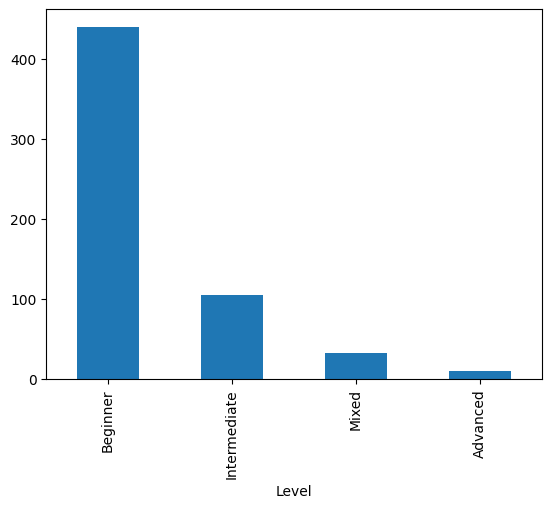

In [21]:
df["Level"].value_counts().plot(kind="bar")

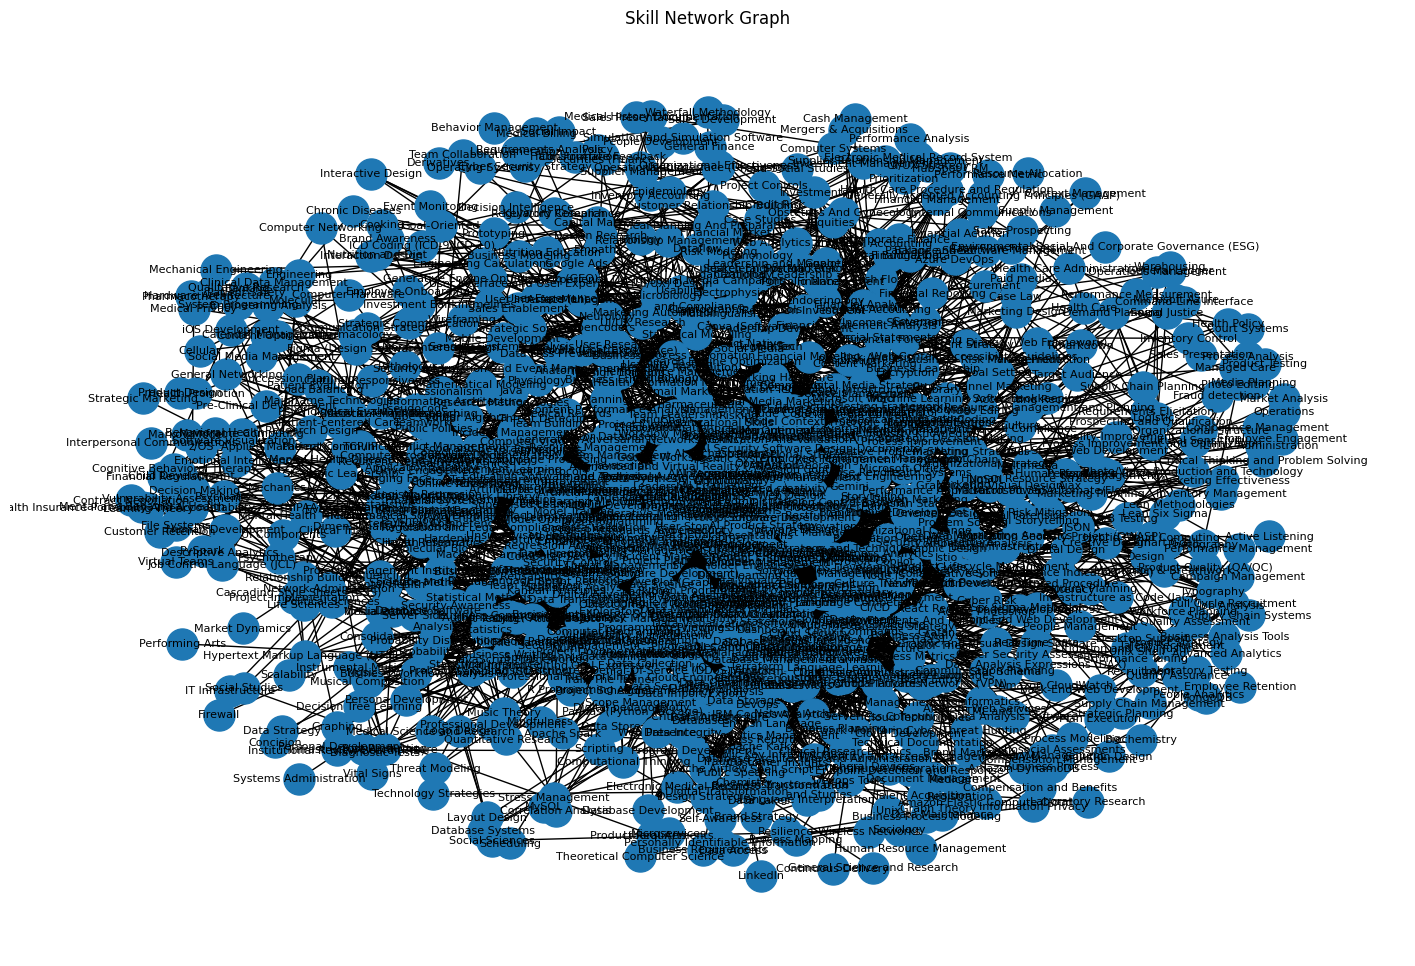

In [22]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations

# buat graph
G = nx.Graph()

# loop semua course
for skills in df["Skills"].dropna():

    # pecah skill
    skill_list = [s.strip() for s in skills.split(",")]

    # buat pasangan skill
    for skill1, skill2 in combinations(skill_list, 2):

        # kalau edge sudah ada
        if G.has_edge(skill1, skill2):
            G[skill1][skill2]["weight"] += 1
        else:
            G.add_edge(skill1, skill2, weight=1)

# ambil edge yang cukup kuat
strong_edges = [
    (u, v)
    for u, v, d in G.edges(data=True)
    if d["weight"] >= 3
]

# subgraph
H = G.edge_subgraph(strong_edges)

# ukuran figure
plt.figure(figsize=(18, 12))

# posisi node
pos = nx.spring_layout(H, k=0.5)

# gambar node
nx.draw_networkx_nodes(
    H,
    pos,
    node_size=500
)

# gambar edge
nx.draw_networkx_edges(
    H,
    pos,
    width=1
)

# label
nx.draw_networkx_labels(
    H,
    pos,
    font_size=8
)

plt.title("Skill Network Graph")
plt.axis("off")
plt.show()

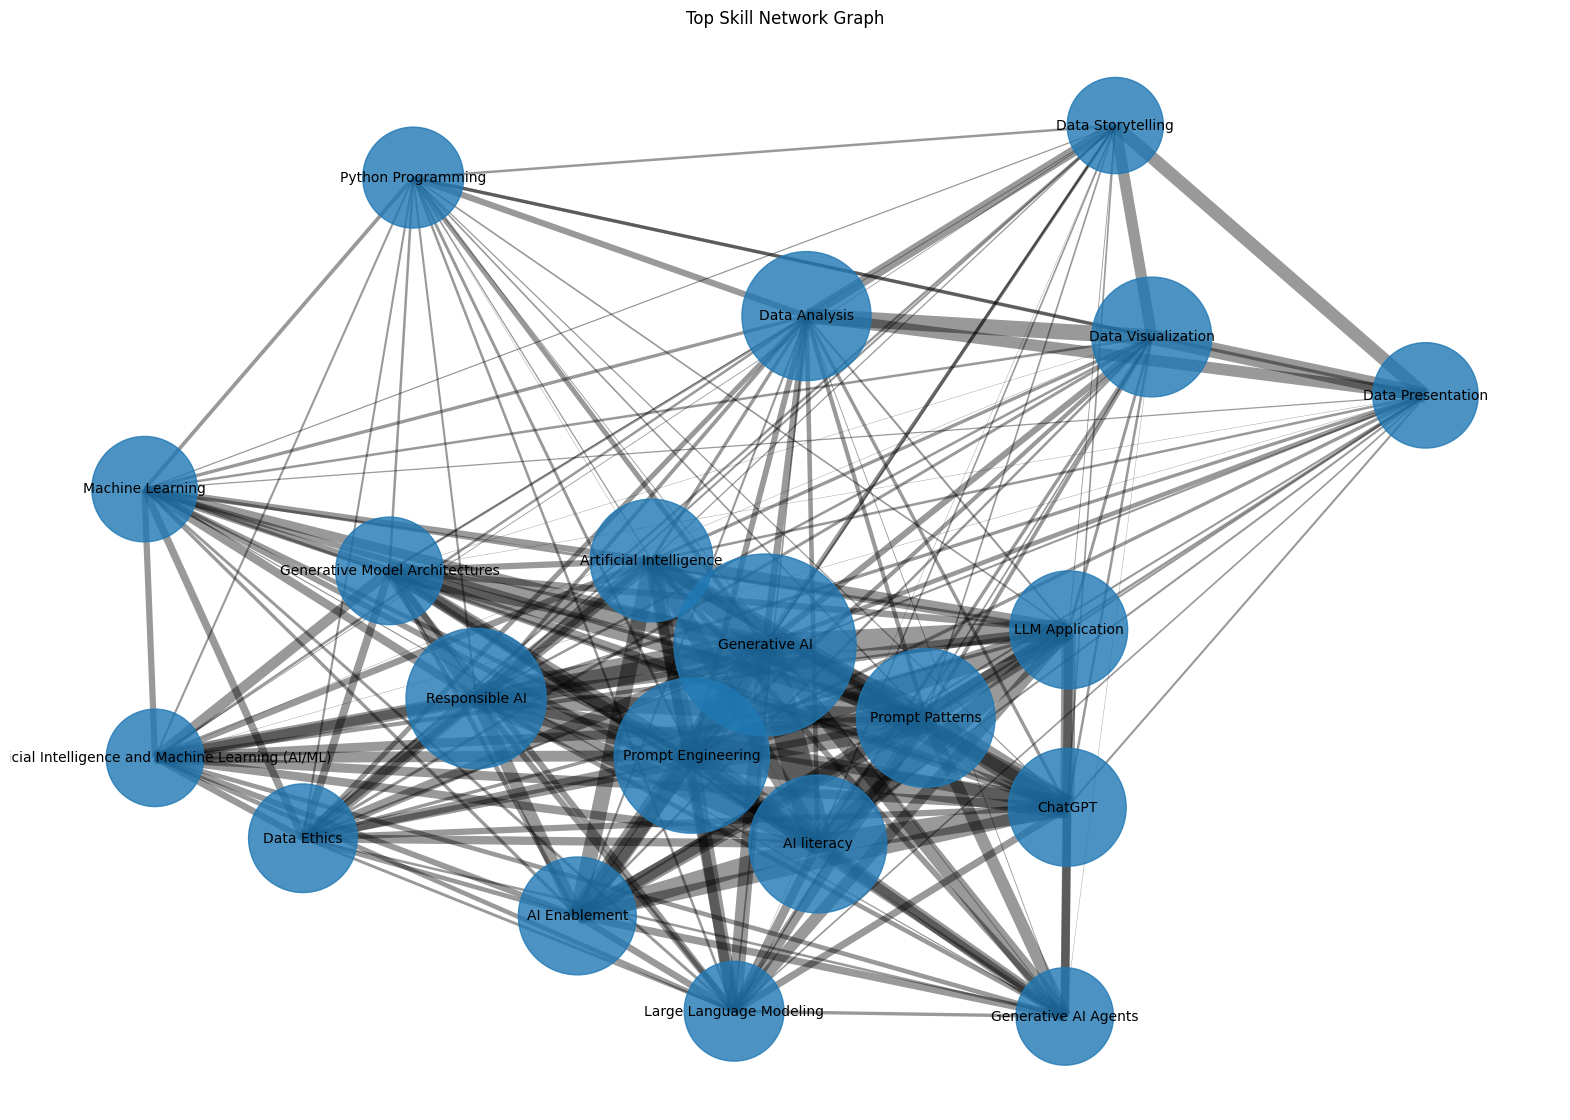

In [23]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter

# ======================
# HITUNG FREKUENSI SKILL
# ======================

all_skills = []

for skills in df["Skills"].dropna():
    skill_list = [s.strip() for s in skills.split(",")]
    all_skills.extend(skill_list)

skill_counts = Counter(all_skills)

# ambil top 20 skill
top_skills = set(
    [skill for skill, count in skill_counts.most_common(20)]
)

# ======================
# BUAT GRAPH
# ======================

G = nx.Graph()

for skills in df["Skills"].dropna():

    skill_list = [
        s.strip()
        for s in skills.split(",")
        if s.strip() in top_skills
    ]

    for skill1, skill2 in combinations(skill_list, 2):

        if G.has_edge(skill1, skill2):
            G[skill1][skill2]["weight"] += 1
        else:
            G.add_edge(skill1, skill2, weight=1)

# ======================
# VISUALISASI
# ======================

plt.figure(figsize=(20, 14))

pos = nx.spring_layout(
    G,
    k=1.2,
    seed=42
)

# ukuran node berdasarkan frekuensi
node_sizes = [
    skill_counts[node] * 120
    for node in G.nodes()
]

# ketebalan edge
edge_widths = [
    G[u][v]["weight"] * 0.3
    for u, v in G.edges()
]

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    alpha=0.8
)

nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    alpha=0.4
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=10
)

plt.title("Top Skill Network Graph")
plt.axis("off")
plt.show()

In [17]:
df.head(20)

,Title,Skills,Level,Link
0,Google AI,"Vibe coding, Prompt Patterns, AI powered crea...",Beginner,https://www.coursera.org/professional-certific...
1,Google Data Analytics,"Data Storytelling, Rmarkdown, Data Visualizat...",Beginner,https://www.coursera.org/professional-certific...
2,Google Project Management,"Quality Management, Project Closure, Scope Ma...",Beginner,https://www.coursera.org/professional-certific...
3,Google AI Essentials,"Prompt Patterns, Google Gemini, Generative AI...",Beginner,https://www.coursera.org/specializations/ai-es...
4,Google Cybersecurity,"Threat Modeling, Network Security, Threat Man...",Beginner,https://www.coursera.org/professional-certific...
5,Google IT Support,"IT Security Architecture, Computer Networking...",Beginner,https://www.coursera.org/professional-certific...
6,Google Digital Marketing & E-commerce,"Data Storytelling, Media Planning, Social Med...",Beginner,https://www.coursera.org/professional-certific...
7,Google UX Design,"Responsive Web Design, Storyboarding, Wirefra...",Beginner,https://www.coursera.org/professional-certific...
8,AI For Everyone,"AI Product Strategy, Responsible AI, Data Eth...",Beginner,https://www.coursera.org/learn/ai-for-everyone
9,Machine Learning,"Unsupervised Learning, Supervised Learning, M...",Beginner,https://www.coursera.org/specializations/machi...


## Extras: 
#### In my case, I only want the name of skills that can be obtained from courses in Coursera

In [18]:
skills_column = df['Skills']

skills_column = [str(skill) if skill is not None else '' for skill in skills_column]

# Concatenate all skills into a single string
all_skills_text = ', '.join(skills_column)

# Split the string into a list of skills
all_skills_list = [skill.strip() for skill in all_skills_text.split(',')]

# Get unique skills
distinct_skills = list(set(all_skills_list))

distinct_skills_df = pd.DataFrame({'Distinct Skills': distinct_skills,'source':"coursera"})
len(distinct_skills)

1907

In [19]:
distinct_skills_df

,Distinct Skills,source
0,Course Development,coursera
1,Data Visualization,coursera
2,Integrated Marketing Communications,coursera
3,Computer Networking,coursera
4,Administration,coursera
...,...,...
1902,Family Support,coursera
1903,Information Assurance,coursera
1904,MySQL,coursera
1905,Data Strategy,coursera


In [20]:
#distinct_skills_df.to_csv("skills_coursera.csv")

### Limitation
Unfortunately due to Coursera's website design, we can only get a max of 84 pages(around 1000 courses) with our code. However, there are actually more than 13k courses in Coursera.

Feel free to improve the code <br />
Thank you!